<a href="https://colab.research.google.com/github/prasadnikhil125-CHAUDHARY/business-data-analysis-ai-ml/blob/main/Project_Workshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Workshop**

In [ ]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import random

https://github.com/YBIFoundation/Visualization/raw/main/RealTimeRetailSalesAnalytics.csv

In [ ]:
# Import dataset
df = pd.read_csv('https://github.com/YBIFoundation/Visualization/raw/main/RealTimeRetailSalesAnalytics.csv')

In [ ]:
df.head()

,Transaction_ID,Timestamp,Category,Product,Quantity,Unit Price,Discount (%),Sales Amount,City,Payment Mode
0,1001,2026-07-25 13:49:10,Grocery,Tea,4,350,10,1260.0,Kolkata,Credit Card
1,1002,2026-07-25 13:49:10,Electronics,Mobile,4,25000,20,80000.0,Mumbai,Debit Card
2,1003,2026-07-25 13:49:10,Fashion,Shoes,5,4500,0,22500.0,Delhi,UPI
3,1004,2026-07-25 13:49:10,Fashion,Shirt,1,1200,20,960.0,Pune,Cash
4,1005,2026-07-25 13:49:10,Electronics,Tablet,1,18000,10,16200.0,Chennai,Cash


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Transaction_ID  1000 non-null   int64  
 1   Timestamp       1000 non-null   object 
 2   Category        1000 non-null   object 
 3   Product         1000 non-null   object 
 4   Quantity        1000 non-null   int64  
 5   Unit Price      1000 non-null   int64  
 6   Discount (%)    1000 non-null   int64  
 7   Sales Amount    1000 non-null   float64
 8   City            1000 non-null   object 
 9   Payment Mode    1000 non-null   object 
dtypes: float64(1), int64(4), object(5)
memory usage: 78.3+ KB


In [ ]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Transaction_ID  1000 non-null   int64         
 1   Timestamp       1000 non-null   datetime64[ns]
 2   Category        1000 non-null   object        
 3   Product         1000 non-null   object        
 4   Quantity        1000 non-null   int64         
 5   Unit Price      1000 non-null   int64         
 6   Discount (%)    1000 non-null   int64         
 7   Sales Amount    1000 non-null   float64       
 8   City            1000 non-null   object        
 9   Payment Mode    1000 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(4)
memory usage: 78.3+ KB


In [ ]:
df['Timestamp']

,Timestamp
0,2026-07-25 13:49:10
1,2026-07-25 13:49:10
2,2026-07-25 13:49:10
3,2026-07-25 13:49:10
4,2026-07-25 13:49:10
...,...
995,2026-07-25 13:49:10
996,2026-07-25 13:49:10
997,2026-07-25 13:49:10
998,2026-07-25 13:49:10


In [ ]:
df['Hour']= df['Timestamp'].dt.hour

In [ ]:
df['Date']=df['Timestamp'].dt.date

In [ ]:
# Calculate KPIs
total_revenue = df["Sales Amount"].sum()

total_transactions = len(df)

average_order = df["Sales Amount"].mean()

total_quantity = df["Quantity"].sum()

print("Revenue :", total_revenue)
print("Transactions :", total_transactions)
print("Average Order :", average_order)
print("Items Sold :", total_quantity)

Revenue : 19475857.5
Transactions : 1000
Average Order : 19475.8575
Items Sold : 3050


# **Create Summary Tables**

In [ ]:
# Top Products
top_products = (
    df.groupby("Product")["Sales Amount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

,Sales Amount
Product,
Laptop,7796750.0
Mobile,3568750.0
Tablet,2889900.0
Smart Watch,1055250.0
Table,757350.0
Shoes,691650.0
Jacket,517180.0
Fan,409080.0
Chair,407330.0


In [ ]:
# Category Sales
category_sales = (
    df.groupby("Category")["Sales Amount"]
      .sum()
      .sort_values()
)

category_sales

,Sales Amount
Category,
Grocery,102507.5
Fashion,1754970.0
Home,1951030.0
Electronics,15667350.0


In [ ]:
# City Sales
city_sales = (
    df.groupby("City")["Sales Amount"]
      .sum()
      .sort_values(ascending=False)
)

city_sales

,Sales Amount
City,
Mumbai,3897909.00
Kolkata,3331101.75
Delhi,3151633.00
Bangalore,2708480.75
Chennai,2390169.25
Pune,2128593.75
Hyderabad,1867970.00


In [ ]:
# Payment Mode
payment_mode = df["Payment Mode"].value_counts()

payment_mode

,count
Payment Mode,
Cash,218
UPI,211
Credit Card,209
Net Banking,193
Debit Card,169


In [ ]:
# Hourly Sales
hourly_sales = (
    df.groupby("Hour")["Sales Amount"]

)

hourly_sales

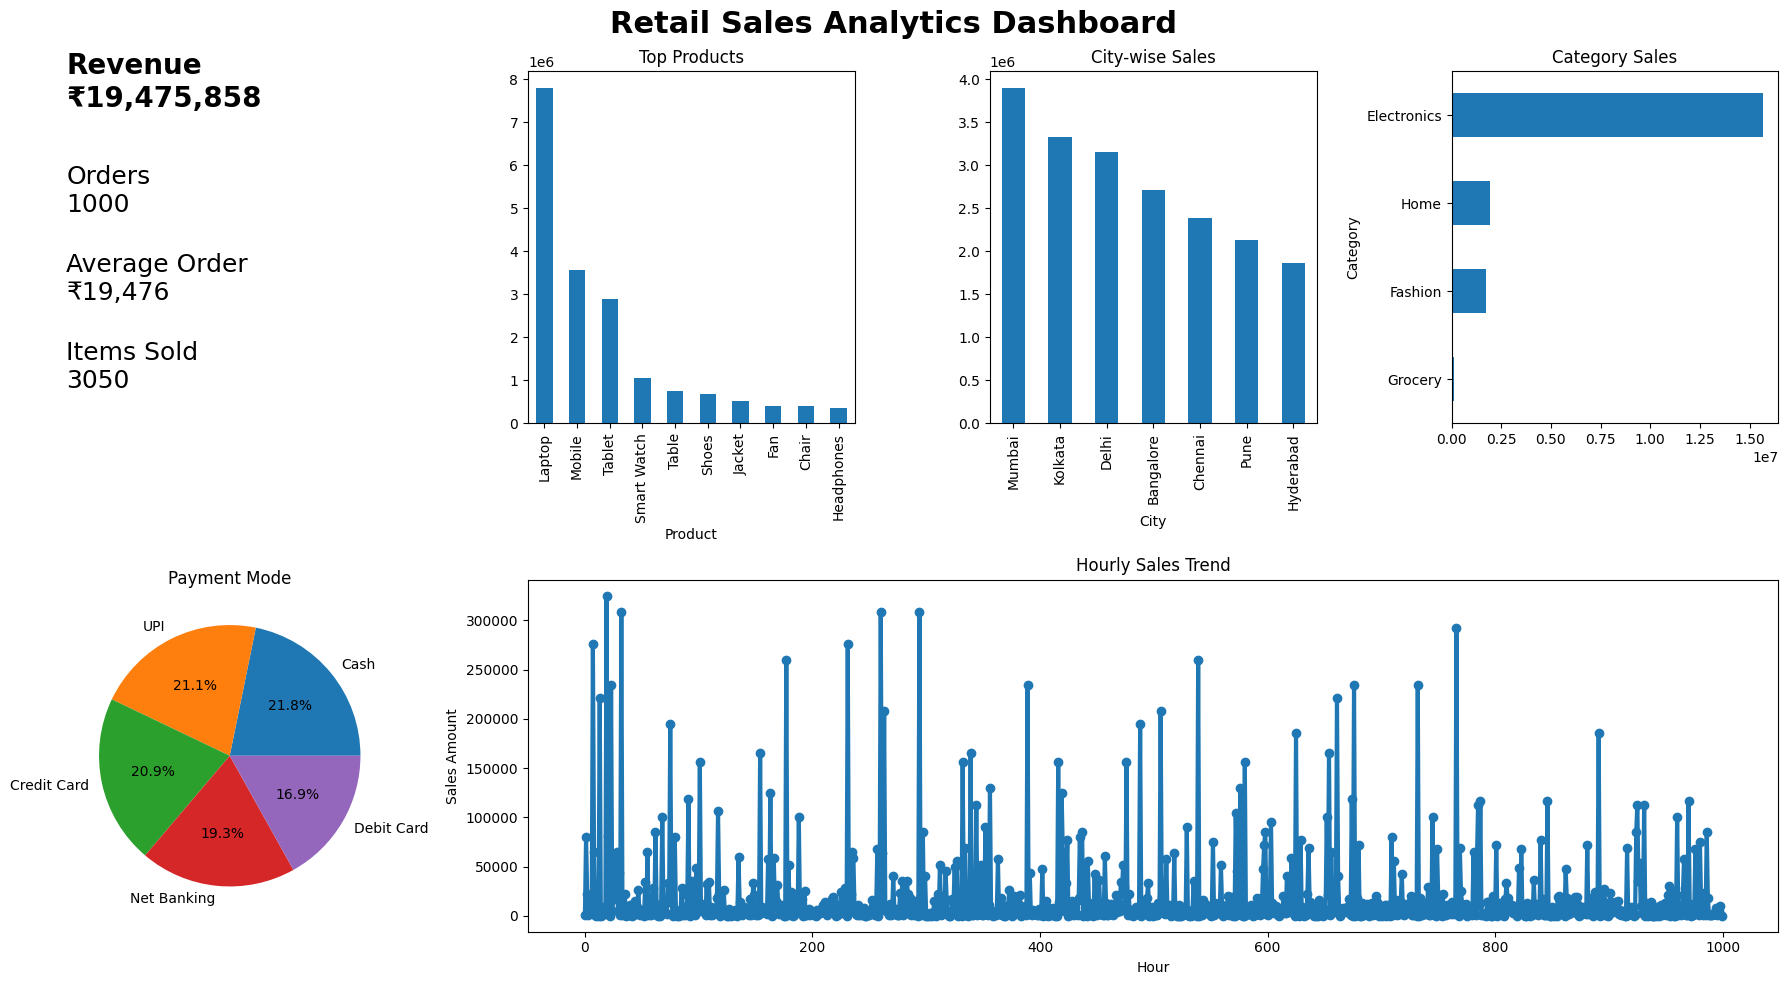

In [ ]:
# Create Dashboard
fig = plt.figure(figsize=(18,10))

# ------------------------------------
# KPI Card
# ------------------------------------

ax1 = plt.subplot(2,4,1)

ax1.axis("off")

ax1.text(0,0.90,
         f"Revenue\n₹{total_revenue:,.0f}",
         fontsize=20,
         fontweight="bold")

ax1.text(0,0.60,
         f"Orders\n{total_transactions}",
         fontsize=18)

ax1.text(0,0.35,
         f"Average Order\n₹{average_order:,.0f}",
         fontsize=18)

ax1.text(0,0.10,
         f"Items Sold\n{total_quantity}",
         fontsize=18)

# ------------------------------------
# Top Products
# ------------------------------------

ax2 = plt.subplot(2,4,2)

top_products.plot(
    kind="bar",
    ax=ax2
)

ax2.set_title("Top Products")

# ------------------------------------
# Top Cities
# ------------------------------------

ax3 = plt.subplot(2,4,3)

city_sales.plot(
    kind="bar",
    ax=ax3
)

ax3.set_title("City-wise Sales")

# ------------------------------------
# Category Sales
# ------------------------------------

ax4 = plt.subplot(2,4,4)

category_sales.plot(
    kind="barh",
    ax=ax4
)

ax4.set_title("Category Sales")

# ------------------------------------
# Payment Distribution
# ------------------------------------

ax5 = plt.subplot(2,4,5)

payment_mode.plot(
    kind="pie",
    autopct="%1.1f%%",
    ax=ax5
)

ax5.set_ylabel("")
ax5.set_title("Payment Mode")

# ------------------------------------
# Hourly Sales Trend
# ------------------------------------

ax6 = plt.subplot(2,4,(6,8))

hourly_sales.plot(
    marker="o",
    linewidth=3,
    ax=ax6
)

ax6.set_title("Hourly Sales Trend")
ax6.set_xlabel("Hour")
ax6.set_ylabel("Sales Amount")

plt.suptitle(
    "Retail Sales Analytics Dashboard",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout()

plt.show()